In [3]:
from pymongo import MongoClient

client = MongoClient("mongodb://localhost:27017")
print(client.list_database_names())

db = client['worldCup']
print(db.list_collection_names())        

coll = db['matches']
doc = coll.find_one()
print(doc)                               

['admin', 'config', 'local', 'worldCup']
['matches']
{'_id': ObjectId('69d666c79fdb7a6388ecfda0'), 'tournament': '1930--uruguay', 'stage': 'Group 1', 'date': datetime.datetime(1930, 7, 13, 0, 0), 'home_team': 'France', 'away_team': 'Mexico', 'home_score': 4, 'away_score': 1, 'venue': 'Estadio Pocitos, Montevideo', 'winner': 'France'}


In [4]:
datos = list(coll.find(
    {},
    {
    "_id": 0,
    "home_team": 1,
    "away_team": 1,
    "tournament": 1,
    "stage": 1,
    "date": 1,
    "home_score": 1,
    "away_score": 1,
    "venue": 1,
    "elo_diff": 1,
    "winner": 1,
    "home_days_since_last_match": 1,
    "away_days_since_last_match": 1
    }
))
print(datos)

[{'tournament': '1930--uruguay', 'stage': 'Group 1', 'date': datetime.datetime(1930, 7, 13, 0, 0), 'home_team': 'France', 'away_team': 'Mexico', 'home_score': 4, 'away_score': 1, 'venue': 'Estadio Pocitos, Montevideo', 'winner': 'France'}, {'tournament': '1930--uruguay', 'stage': 'Group 1', 'date': datetime.datetime(1930, 7, 15, 0, 0), 'home_team': 'Argentina', 'away_team': 'France', 'home_score': 1, 'away_score': 0, 'venue': 'Estadio Parque Central, Montevideo', 'winner': 'Argentina'}, {'tournament': '1930--uruguay', 'stage': 'Group 1', 'date': datetime.datetime(1930, 7, 16, 0, 0), 'home_team': 'Chile', 'away_team': 'Mexico', 'home_score': 3, 'away_score': 0, 'venue': 'Estadio Parque Central, Montevideo', 'winner': 'Chile'}, {'tournament': '1930--uruguay', 'stage': 'Group 1', 'date': datetime.datetime(1930, 7, 19, 0, 0), 'home_team': 'Chile', 'away_team': 'France', 'home_score': 1, 'away_score': 0, 'venue': 'Estadio Centenario, Montevideo', 'winner': 'Chile'}, {'tournament': '1930--ur

Predicción real

In [8]:
from sklearn.preprocessing import LabelEncoder
import numpy as np

# 1. Primero instanciamos todos los encoders que necesita tu código
le_team = LabelEncoder()
le_tournament = LabelEncoder()
le_stage = LabelEncoder()
le_winner = LabelEncoder()

# 2. Extraemos los textos de los datos para entrenar (fit) los mapeos correctamente
todos_equipos = list(set([d.get("home_team", "Unknown") for d in datos] + [d.get("away_team", "Unknown") for d in datos]))
le_team.fit(todos_equipos)

todos_torneos = list(set([d.get("tournament", "Unknown") for d in datos]))
le_tournament.fit(todos_torneos)

todos_fases = list(set([d.get("stage", "Unknown") for d in datos]))
le_stage.fit(todos_fases)

todos_ganadores = list(set([d.get("winner", "Unknown") for d in datos]))
le_winner.fit(todos_ganadores)

# 3. Ahora ya puedes hacer el procesamiento de tu compañero de forma segura
home_team = le_team.transform([d.get("home_team", "Unknown") for d in datos])
away_team = le_team.transform([d.get("away_team", "Unknown") for d in datos])
tournament = le_tournament.transform([d.get("tournament", "Unknown") for d in datos])
stage = le_stage.transform([d.get("stage", "Unknown") for d in datos])
y = le_winner.transform([d.get("winner", "Unknown") for d in datos])

# Construimos la matriz X sin fallos
X = np.column_stack([
    home_team,
    away_team,
    tournament,
    stage,
    [d.get("elo_diff", 0) for d in datos],
    [d.get("home_days_since_last_match", 0) if d.get("home_days_since_last_match") is not None else 0 for d in datos],
    [d.get("away_days_since_last_match", 0) if d.get("away_days_since_last_match") is not None else 0 for d in datos]
])

print("Datos preparados con éxito sin NameError")
print("-" * 40)

# Prints de diagnóstico
print("team mapping:", dict(zip(le_team.classes_, le_team.transform(le_team.classes_))))
print("winner classes:", le_winner.classes_)
print("y counts:", np.bincount(y))

Datos preparados con éxito sin NameError
----------------------------------------
team mapping: {np.str_(')'): np.int64(0), np.str_('13:00     France'): np.int64(1), np.str_('13:00    Argentina'): np.int64(2), np.str_('13:00   Argentina'): np.int64(3), np.str_('13:00   Brazil'): np.int64(4), np.str_('13:00   France'): np.int64(5), np.str_('13:00   Netherlands'): np.int64(6), np.str_('13:30    Algeria'): np.int64(7), np.str_('13:30    Argentina'): np.int64(8), np.str_('13:30    Germany'): np.int64(9), np.str_('13:30    South Korea'): np.int64(10), np.str_('13:30   Honduras'): np.int64(11), np.str_('13:30   Netherlands'): np.int64(12), np.str_('13:30   New Zealand'): np.int64(13), np.str_('13:30   Portugal'): np.int64(14), np.str_('13:30   Slovakia'): np.int64(15), np.str_('15:00          Belgium'): np.int64(16), np.str_('15:00          Colombia'): np.int64(17), np.str_('15:00          England'): np.int64(18), np.str_('15:00        Sweden'): np.int64(19), np.str_('15:00       Brazil'): n

BLOQUE MACHINE LEARNING


In [18]:
import re
import pandas as pd
import numpy as np
from pymongo import MongoClient
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

# Importación de todos los Modelos
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# 1. CONEXIÓN A MONGO
client = MongoClient("mongodb://localhost:27017/")
db = client["worldCup"]
coll = db["matches"]
datos = list(coll.find({}, {"_id": 0}))

# 2. FUNCIÓN DE LIMPIEZA TOTAL (Fuera horas, penaltis y restos de texto)
def limpiar_equipo_perfecto(nombre):
    n = str(nombre).strip()
    # Eliminar horas al principio (ej: '13:00   France' -> 'France')
    n = re.sub(r'^\d{2}:\d{2}\s+', '', n)
    # Si hay espacios grandes, nos quedamos solo con la primera parte real (limpia prórrogas)
    if "   " in n: n = n.split("   ")[0]
    if "  " in n: n = n.split("  ")[0]
    # Quitar el conector 'v' de partidos mal formateados
    if " v " in n: n = n.split(" v ")[0]
    # Borrar cualquier carácter que no sea una letra o espacio (ej: paréntesis sueltos)
    n = re.sub(r'[^a-zA-Z\sÀ-ÿ\d\']', '', n)
    return n.strip()

# Aplicar la limpieza al conjunto de datos de MongoDB
for d in datos:
    d['home_team'] = limpiar_equipo_perfecto(d.get('home_team', 'Unknown'))
    d['away_team'] = limpiar_equipo_perfecto(d.get('away_team', 'Unknown'))
    
    ganador_sucio = d.get('winner')
    if pd.isna(ganador_sucio) or ganador_sucio == "" or ganador_sucio is None:
        d['winner_clean'] = 'Draw'
    else:
        d['winner_clean'] = limpiar_equipo_perfecto(ganador_sucio)

df = pd.DataFrame(datos)

# 3. TRANSFORMACIÓN A NÚMEROS SIN DUPLICADOS EXTRAÑOS
le_team = LabelEncoder()
le_winner = LabelEncoder()

# Entrenamos el encoder con todos los nombres ya limpios
todos_los_equipos = pd.concat([df['home_team'], df['away_team'], df['winner_clean']]).unique()
le_team.fit(todos_los_equipos)

df['home_idx'] = le_team.transform(df['home_team'])
df['away_idx'] = le_team.transform(df['away_team'])
df['target'] = le_winner.fit_transform(df['winner_clean'])

# 4. PREPARACIÓN DE MATRICES (Variables X e y)
columnas_x = ['home_idx', 'away_idx', 'elo_diff']
X = df[columnas_x].fillna(0)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. DICCIONARIO DE MODELOS
modelos = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "Extra Trees": ExtraTreesClassifier(n_estimators=100, random_state=42)
}

# 6. ENTRENAR Y EVALUAR EN EL ACTO
print(f"===== PARTIDOS PROCESADOS CON ENCODING LIMPIO: {len(df)} =====\n")

for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    precision = accuracy_score(y_test, y_pred)
    print(f"{nombre}: {precision * 100:.2f}%")

===== PARTIDOS PROCESADOS CON ENCODING LIMPIO: 1896 =====

Random Forest: 50.00%
Decision Tree: 60.26%
KNN: 25.53%
Naive Bayes: 23.68%


/Users/macbookpro/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression: 25.00%
SVM: 24.47%
Gradient Boosting: 63.95%
Extra Trees: 49.74%


In [19]:
import numpy as np
from sklearn.ensemble import GradientBoostingRegressor

# Entrenamos los dos modelos usando el algoritmo ganador (Gradient Boosting)
model_goals_home = GradientBoostingRegressor(random_state=42).fit(
    X_train, df.loc[X_train.index, "home_score"]
)
model_goals_away = GradientBoostingRegressor(random_state=42).fit(
    X_train, df.loc[X_train.index, "away_score"]
)


def predecir_marcador(local, visitante):
    try:
        # Transformamos los nombres a los índices numéricos correspondientes
        h = le_team.transform([local])[0]
        a = le_team.transform([visitante])[0]

        # Usamos elo_diff = 0 por defecto si no lo tenemos
        input_data = np.array([[h, a, 0]])

        # Predecimos goles
        goles_h = model_goals_home.predict(input_data)[0]
        goles_a = model_goals_away.predict(input_data)[0]

        # Forzamos a que no existan goles negativos en la predicción
        goles_h = max(0, goles_h)
        goles_a = max(0, goles_a)

        print(
            f"Predicción marcador: {local} {goles_h:.1f} - {goles_a:.1f} {visitante}"
        )

    except ValueError:
        print(
            f"Error: Uno de los equipos ('{local}' o '{visitante}') no está en la base de datos."
        )


# Probamos el sistema
predecir_marcador("Spain", "Germany")

Predicción marcador: Spain 1.4 - 1.5 Germany


/Users/macbookpro/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(
/Users/macbookpro/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(


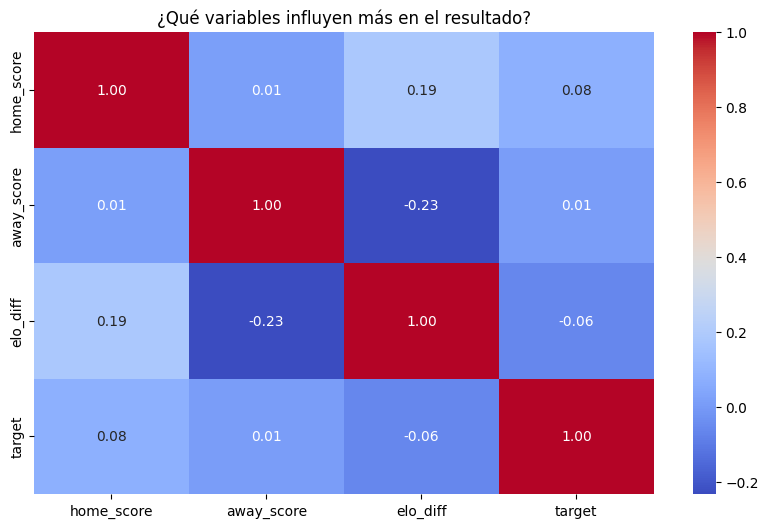

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.heatmap(
    df[["home_score", "away_score", "elo_diff", "target"]].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
)
plt.title("¿Qué variables influyen más en el resultado?")
plt.show()

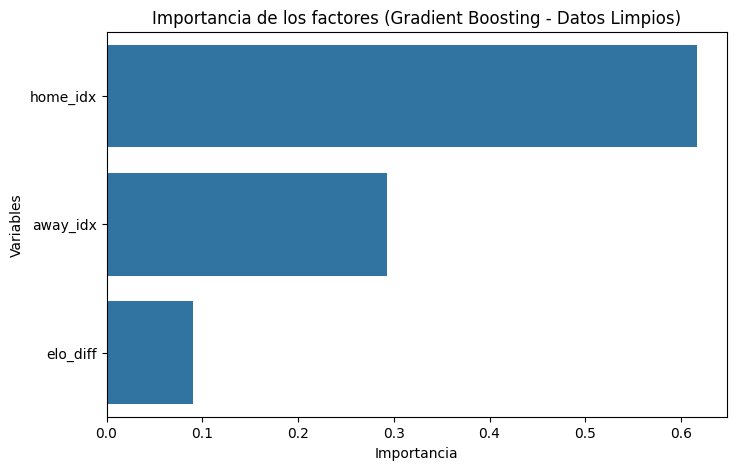

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

# CORRECCIÓN: Seleccionamos el modelo que mejor rendimiento tuvo en el diccionario
modelo_elegido = modelos["Gradient Boosting"]

importances = modelo_elegido.feature_importances_
features = columnas_x

plt.figure(figsize=(8, 5))
sns.barplot(x=importances, y=features)
plt.title("Importancia de los factores (Gradient Boosting - Datos Limpios)")
plt.xlabel("Importancia")
plt.ylabel("Variables")
plt.show()

# CORRELACIÓN RESULTADOS DEL ENCUENTRO - ALTITUD

Obteniendo altitudes reales para 226 sedes únicas...
Procesadas 5/226 sedes...
Procesadas 10/226 sedes...
Procesadas 15/226 sedes...
Procesadas 20/226 sedes...
Procesadas 25/226 sedes...
Procesadas 30/226 sedes...
Procesadas 35/226 sedes...
Procesadas 40/226 sedes...
Procesadas 45/226 sedes...
Procesadas 50/226 sedes...
Procesadas 55/226 sedes...
Procesadas 60/226 sedes...
Procesadas 65/226 sedes...
Procesadas 70/226 sedes...
Procesadas 75/226 sedes...
Procesadas 80/226 sedes...
Procesadas 85/226 sedes...
Procesadas 90/226 sedes...
Procesadas 95/226 sedes...
Procesadas 100/226 sedes...
Procesadas 105/226 sedes...
Procesadas 110/226 sedes...
Procesadas 115/226 sedes...
Procesadas 120/226 sedes...
Procesadas 125/226 sedes...
Procesadas 130/226 sedes...
Procesadas 135/226 sedes...
Procesadas 140/226 sedes...
Procesadas 145/226 sedes...
Procesadas 150/226 sedes...
Procesadas 155/226 sedes...
Procesadas 160/226 sedes...
Procesadas 165/226 sedes...
Procesadas 170/226 sedes...
Procesadas 175/

/var/folders/sn/cmm7cs3n4cx_y5bw5m10kp200000gn/T/ipykernel_52400/2323291710.py:104: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=columnas_x, palette="magma")


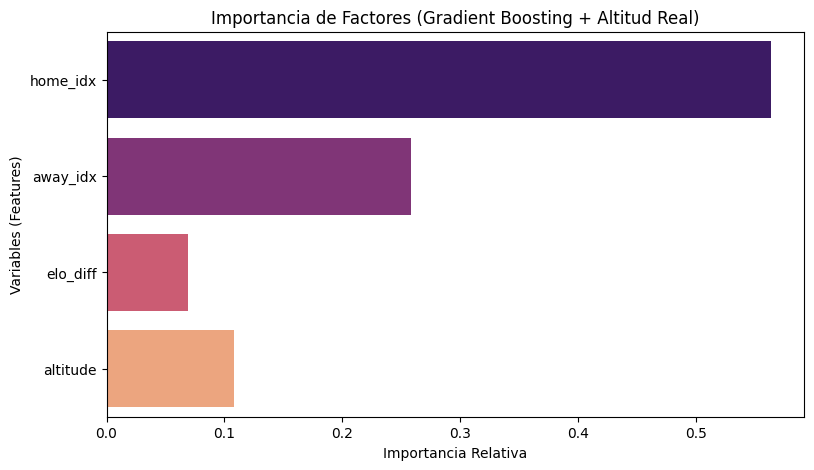

In [ ]:
import re
import requests
import pandas as pd
import numpy as np
from pymongo import MongoClient
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter

# 1. CONEXIÓN A MONGO
client = MongoClient("mongodb://localhost:27017/")
db = client["worldCup"] 
coll = db["matches"]
datos = list(coll.find({}, {"_id": 0}))
df = pd.DataFrame(datos)

# 2. LIMPIEZA (Evita que se rompan los nombres de los equipos)
def limpiar_equipo_perfecto(nombre):
    n = str(nombre).strip()
    n = re.sub(r'^\d{2}:\d{2}\s+', '', n) # Quita horas
    if "   " in n: n = n.split("   ")[0] # Quita prórrogas/penaltis
    if "  " in n: n = n.split("  ")[0]
    if " v " in n: n = n.split(" v ")[0]
    n = re.sub(r'[^a-zA-Z\sÀ-ÿ\d\']', '', n) # Quita símbolos extraños
    return n.strip()

df['home_team'] = df['home_team'].apply(limpiar_equipo_perfecto)
df['away_team'] = df['away_team'].apply(limpiar_equipo_perfecto)
df['winner_clean'] = df['winner'].fillna('Draw').apply(limpiar_equipo_perfecto)

# 3. ALTITUD AUTOMÁTICA AUTOMATIZADA y SEGURA
geolocator = Nominatim(user_agent="world_cup_predictor_v2")
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)

# Limpiamos las sedes vacías antes de buscar
df['venue'] = df['venue'].fillna('Unknown')
sedes_unicas = df['venue'].unique()
mapeo_altitudes = {}

print(f"Obteniendo altitudes reales para {len(sedes_unicas)} sedes únicas...")

for i, sede in enumerate(sedes_unicas, 1):
    if sede == 'Unknown':
        mapeo_altitudes[sede] = 50
        continue
    try:
        # Paso 1: Buscar coordenadas de la sede
        location = geolocator.geocode(sede, timeout=10)
        if location:
            # Paso 2: Consultar API de Open-Elevation
            url = f"https://api.open-elevation.com/api/v1/lookup?locations={location.latitude},{location.longitude}"
            response = requests.get(url, timeout=10).json()
            altitud = response['results'][0]['elevation']
            mapeo_altitudes[sede] = altitud
        else:
            mapeo_altitudes[sede] = 50 # Valor por defecto (nivel del mar aproximado)
    except:
        mapeo_altitudes[sede] = 50
    
    # Imprime el progreso para que sepas que sigue vivo
    if i % 5 == 0 or i == len(sedes_unicas):
        print(f"Procesadas {i}/{len(sedes_unicas)} sedes...")

# Mapeamos las altitudes calculadas al DataFrame principal
df['altitude'] = df['venue'].map(mapeo_altitudes)

# 4. TRANSFORMACIÓN A NÚMEROS
le_team = LabelEncoder()
le_winner = LabelEncoder()

todos_equipos = pd.concat([df['home_team'], df['away_team'], df['winner_clean']]).unique()
le_team.fit(todos_equipos)

df['home_idx'] = le_team.transform(df['home_team'])
df['away_idx'] = le_team.transform(df['away_team'])
df['target'] = le_winner.fit_transform(df['winner_clean'])

# 5. ENTRENAMIENTO CON EL MEJOR MODELO (Gradient Boosting)
columnas_x = ['home_idx', 'away_idx', 'elo_diff', 'altitude']
X = df[columnas_x].fillna(0)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Usamos el modelo campeón
model_win = GradientBoostingClassifier(random_state=42)
model_win.fit(X_train, y_train)

# 6. RESULTADOS FINAL
y_pred = model_win.predict(X_test)
print("\n" + "="*40)
print(f"Precisión final (Gradient Boosting + Altitud): {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("="*40 + "\n")

# 7. GRÁFICA DE IMPORTANCIA DE FACTORES
importances = model_win.feature_importances_

plt.figure(figsize=(9, 5))
sns.barplot(x=importances, y=columnas_x, palette="magma")
plt.title("Importancia de Factores (Gradient Boosting + Altitud Real)")
plt.xlabel("Importancia Relativa")
plt.ylabel("Variables (Features)")
plt.show()


## CORRELACIÓN CLIMA DEL PARTIDO - RESULTADO DEL ENCUENTRO 

Obtenemos el clima real de cada partido con la API

In [1]:
import pandas as pd
from pymongo import MongoClient
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
import openmeteo_requests
import requests_cache
from retry_requests import retry
import time


# CONFIGURACIÓN DE APIS Y CACHÉ ---
# Guardamos los datos en caché para no repetir peticiones a internet
cache_session = requests_cache.CachedSession('.cache', expire_after=-1)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)


geolocator = Nominatim(user_agent="world_cup_final_research_jaime", timeout=10)
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=2.0, error_wait_seconds=5.0)


# CONEXIÓN Y LIMPIEZA INICIAL
client = MongoClient("mongodb://localhost:27017/")
db = client["worldCup"]
df = pd.DataFrame(list(db["matches"].find({}, {"_id": 0})))


# 1. Convertimos a fecha y eliminamos las que estén vacías (evita el error NaT)
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.dropna(subset=['date'])


# FUNCIONES DE APOYO
def limpiar_nombre_geografico(nombre):
   """Quita horas y ruidos de los nombres (ej: '20:30 France' -> 'France')"""
   n = str(nombre).strip()
   return n.split()[-1] if " " in n else n


memo_coords = {}


def get_coords(name):
   """Busca coordenadas GPS evitando repetir búsquedas ya hechas."""
   nombre_limpio = limpiar_nombre_geografico(name)
   if nombre_limpio in memo_coords: return memo_coords[nombre_limpio]
  
   try:
       loc = geocode(nombre_limpio)
       if loc:
           memo_coords[nombre_limpio] = (loc.latitude, loc.longitude)
           return memo_coords[nombre_limpio]
   except:
       pass
   return (0, 0)


def get_weather_data(lat, lon, date):
   """Consulta el clima histórico en la API de Open-Meteo."""
   # Si las coordenadas fallaron o la fecha es nula, devolvemos valores neutros
   if lat == 0 or pd.isnull(date):
       return 22.0, 50.0, 10.0
  
   try:
       date_str = date.strftime('%Y-%m-%d')
       url = "https://archive-api.open-meteo.com/v1/archive"
       params = {
           "latitude": lat, "longitude": lon,
           "start_date": date_str, "end_date": date_str,
           "daily": ["apparent_temperature_max", "relative_humidity_2m_max", "wind_speed_10m_max"]
       }
       responses = openmeteo.weather_api(url, params=params)
       res = responses[0].Daily()
       # Orden: Temperatura Aparente, Humedad, Viento
       return (res.Variables(0).ValuesAsNumpy()[0],
               res.Variables(1).ValuesAsNumpy()[0],
               res.Variables(2).ValuesAsNumpy()[0])
   except:
       return 22.0, 50.0, 10.0


# PROCESAMIENTO PRINCIPAL ---
print(f"Iniciando proceso para {len(df)} partidos...")


# 1. Pre-calculamos coordenadas para ir más rápido
sedes_coords = {sede: get_coords(sede) for sede in df['venue'].unique()}
paises_coords = {pais: get_coords(pais) for pais in pd.concat([df['home_team'], df['away_team']]).unique()}


print("Coordenadas obtenidas. Consultando clima y calculando Shock Térmico...")


clima_partidos = []
for i, row in df.iterrows():
   # Coordenadas del estadio
   lat_m, lon_m = sedes_coords[row['venue']]
   # Clima real del partido
   temp, hum, wind = get_weather_data(lat_m, lon_m, row['date'])
  
   # Clima base de los equipos (usamos una fecha de referencia: Junio 2022)
   lat_h, lon_h = paises_coords[row['home_team']]
   lat_a, lon_a = paises_coords[row['away_team']]
  
   t_base_h, _, _ = get_weather_data(lat_h, lon_h, pd.to_datetime('2022-06-15'))
   t_base_a, _, _ = get_weather_data(lat_a, lon_a, pd.to_datetime('2022-06-15'))


   # Guardamos los resultados
   clima_partidos.append({
       'match_temp': temp,
       'match_hum': hum,
       'match_wind': wind,
       'shock_home': temp - t_base_h,
       'shock_away': temp - t_base_a
   })
  
   if i % 100 == 0:
       print(f"Progreso: {i}/{len(df)} partidos...")


# GUARDADO FINAL ---
df_final = pd.concat([df.reset_index(drop=True), pd.DataFrame(clima_partidos)], axis=1)
df_final.to_csv("mundiales_clima_pro.csv", index=False)


print("-" * 30)
print("Proceso completado")
print(f"Archivo guardado como: mundiales_clima_pro.csv")
print(f"Columnas añadidas: match_temp, match_hum, match_wind, shock_home, shock_away")

Iniciando proceso para 1892 partidos...
Coordenadas obtenidas. Consultando clima y calculando Shock Térmico...
Progreso: 0/1892 partidos...
Progreso: 100/1892 partidos...
Progreso: 200/1892 partidos...
Progreso: 300/1892 partidos...
Progreso: 400/1892 partidos...
Progreso: 500/1892 partidos...
Progreso: 600/1892 partidos...
Progreso: 700/1892 partidos...
Progreso: 800/1892 partidos...
Progreso: 900/1892 partidos...
Progreso: 1000/1892 partidos...
Progreso: 1100/1892 partidos...
Progreso: 1200/1892 partidos...
Progreso: 1300/1892 partidos...
Progreso: 1400/1892 partidos...
Progreso: 1500/1892 partidos...
Progreso: 1600/1892 partidos...
Progreso: 1700/1892 partidos...
Progreso: 1800/1892 partidos...
------------------------------
Proceso completado
Archivo guardado como: mundiales_clima_pro.csv
Columnas añadidas: match_temp, match_hum, match_wind, shock_home, shock_away



===== RESULTADOS =====

Random Forest: 77.04%
Decision Tree: 58.31%
KNN: 50.92%
Naive Bayes: 53.30%
Logistic Regression: 55.15%
SVM: 54.62%
Gradient Boosting: 62.27%
Extra Trees: 84.43%

Mejor modelo: Extra Trees
Precisión máxima: 84.43%


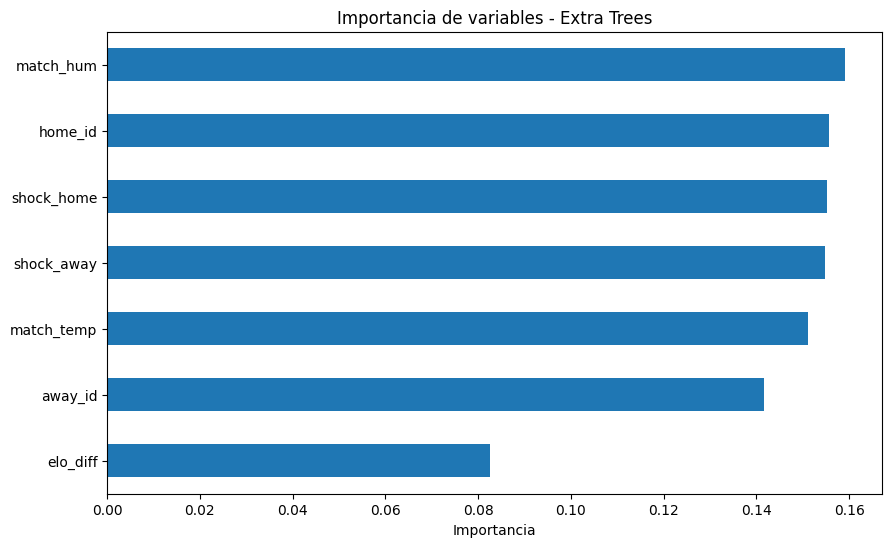

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

# Modelos
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import ExtraTreesClassifier

# CARGA DE DATOS 
df = pd.read_csv("mundiales_clima_pro.csv")

# DEFINIR GANADOR
def definir_ganador(row):
    if row['home_score'] > row['away_score']:
        return 0  # Home

    if row['away_score'] > row['home_score']:
        return 1  # Away

    return 2  # Draw

df['target'] = df.apply(definir_ganador, axis=1)

# CODIFICAR EQUIPOS 
le = LabelEncoder()

todos_equipos = pd.concat([
    df['home_team'],
    df['away_team']
]).unique()

le.fit(todos_equipos)

df['home_id'] = le.transform(df['home_team'])
df['away_id'] = le.transform(df['away_team'])

# FEATURES 
features = [
    'home_id',
    'away_id',
    'elo_diff',
    'match_temp',
    'match_hum',
    'shock_home',
    'shock_away'
]

X = df[features].fillna(0)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# MODELOS 
modelos = {
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "Naive Bayes": GaussianNB(),

    "Logistic Regression": LogisticRegression(
        max_iter=5000,
        solver='lbfgs'
    ),

    "SVM": SVC(),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=100,
        random_state=42
    )
}

# ENTRENAR Y EVALUAR
resultados = {}

print("\n===== RESULTADOS =====\n")

for nombre, modelo in modelos.items():

    modelo.fit(X_train, y_train)

    y_pred = modelo.predict(X_test)

    precision = accuracy_score(y_test, y_pred)

    resultados[nombre] = precision

    print(f"{nombre}: {precision * 100:.2f}%")

# --- G. MEJOR MODELO ---
mejor_modelo_nombre = max(resultados, key=resultados.get)

print(f"\nMejor modelo: {mejor_modelo_nombre}")
print(f"Precisión máxima: {resultados[mejor_modelo_nombre] * 100:.2f}%")

# --- H. IMPORTANCIA DE VARIABLES ---
# Solo si el mejor modelo tiene feature_importances_

mejor_modelo = modelos[mejor_modelo_nombre]

if hasattr(mejor_modelo, "feature_importances_"):

    plt.figure(figsize=(10, 6))

    importancias = pd.Series(
        mejor_modelo.feature_importances_,
        index=features
    ).sort_values()

    importancias.plot(kind='barh')

    plt.title(f"Importancia de variables - {mejor_modelo_nombre}")

    plt.xlabel("Importancia")

    plt.show()